In [181]:
import numpy as np
import pandas as pd
from WFlib.tools.extractor import array_path
# Make the dataset (Read in Shadowsocks flows)
root_dir = "/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract"

array_dir = f'{root_dir}/arrays'
db_file = f'{root_dir}/database.csv'
protocol = "vmess"

db = pd.read_csv(db_file).query(f"protocol == '{protocol}'")[['host', 'id', 'stream', 'transport', 'sni']]

flows = []

def load_flows(paths):
    for path in paths:
        data = np.load(path)
        if len(data['direction']) < 15:
            continue
        # Truncate the flow to 30 packets
        flow = data['direction'][:15] * data['length'][:15]
        flows.append(flow)

paths = db.apply(lambda row: f'{array_dir}/{array_path(row["host"], row["id"], row["transport"], row["stream"], protocol)}', axis=1)
load_flows(paths)

In [215]:
import pickle
protocol = "shadowsocks"

# with open(f'{protocol}.pkl', 'wb') as f:
#     pickle.dump(flows, f)

with open(f'{protocol}.pkl', 'rb') as f:
    flows = pickle.load(f)

In [183]:
with open(fr'/data/exp/lxyu/Dataset/WF/VisualSeg/packet_size/{protocol}.npz', 'rb') as f:
    packet_size_count = pickle.load(f)

In [2]:
%load_ext autoreload
%autoreload 2

# VMess: train :400 test :20000-24000 [3, 4] lambda_penalty=0.001
# Shadowsocks: train :40 test :20000-24000 [4, 5] lambda_penalty=0.01
# Trojan: train :40 test :20000-24000 [12,13] lambda_penalty=0.001
import pickle

from WFlib.tools.extractor import *
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def fit_uniform_binner(v):
    return PacketSizeBinner.fit_uniform(LOWER_BOUND, UPPER_BOUND, v)

UPPER_BOUND = 1500
LOWER_BOUND = -1500
WINDOW_SIZE = 2
PROTOCOLS = ['vmess', 'shadowsocks', 'trojan']
PROTOCOLS_DISPLAY = {'vmess': 'VMess', 'shadowsocks': 'Shadowsocks', 'trojan': 'Trojan'}

STRIP_INDICES = {'vmess': [3, 4], 'shadowsocks': [4, 5], 'trojan': [3, 4]}
LAMBDA_PENALTY = {'vmess': 0.001, 'shadowsocks': 0.01, 'trojan': 0.002}
TRAIN_SAMPLES = {'vmess': 400, 'shadowsocks': 40, 'trojan': 4}
VOCABULARY_RANGE = [1, 2, 4, 7, 9, 11, 30, 50, 70, 90, 101, 300, 500, 700, 900, 1001, 1400, 1800, 2000, 2400, 2800]

precision, recall = {'vmess': [], 'shadowsocks': [], 'trojan': []}, {'vmess': [], 'shadowsocks': [], 'trojan': []}
objective = dict()
vocab_star = dict()

for protocol in PROTOCOLS:
    # Data preparation
    with open(f'{protocol}.pkl', 'rb') as f:
        flows = pickle.load(f)

    for vocabulary_size in VOCABULARY_RANGE:
        # vocabulary_sizes.append(vocabulary_size)
        flows_train = flows[:TRAIN_SAMPLES[protocol]]
        flows_test = flows[4000:]
        window_type = set()
        for flow in flows_test:
            binned_flow = uniform_bin(flow, LOWER_BOUND, UPPER_BOUND, vocabulary_size)
            window_type.add(tuple(binned_flow[STRIP_INDICES[protocol]]))

        binner = PacketSizeBinner.fit_uniform(
            LOWER_BOUND, UPPER_BOUND, vocabulary_size=vocabulary_size
        )
        # binner = PacketSizeBinner.fit_distribution(packet_size_count, vocabulary_size)

        ngram_db = train_ngram_db(
            flows_train, STRIP_INDICES[protocol], WINDOW_SIZE, binner
        )
        p, r = evaluate_ngram(
            flows_test, STRIP_INDICES[protocol], WINDOW_SIZE, ngram_db, binner
        )
        precision[protocol].append(p)
        recall[protocol].append(r)

    rows = sweep_vocabulary_objective(
        flows[:8000],
        STRIP_INDICES[protocol],
        WINDOW_SIZE,
        VOCABULARY_RANGE,
        fit_binner=fit_uniform_binner,
        lambda_penalty=LAMBDA_PENALTY[protocol],
    )
    df_obj = pd.DataFrame(rows)

    objective[protocol] = df_obj["objective"]
    vocab_star[protocol] = int(df_obj.loc[df_obj["objective"].idxmax(), "vocabulary_size"])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


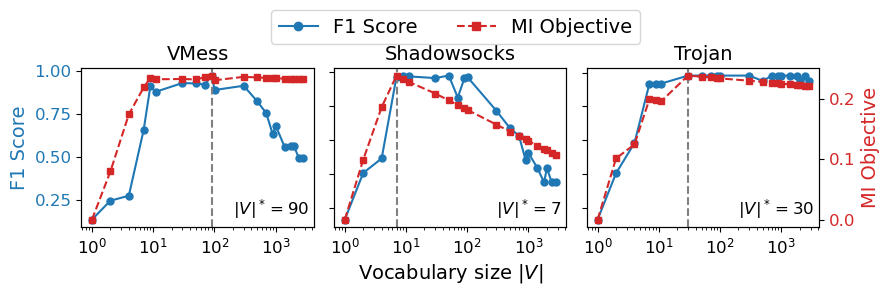

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=True)
color_f1 = "tab:blue"
color_obj = "tab:red"

# We'll store the twin axes to access them later if needed
secondary_axes = []

for i, (ax1, protocol) in enumerate(zip(axes, PROTOCOLS)):
    f1_scores = [
        2 * p * r / (p + r) if (p + r) > 0 else 0.0
        for p, r in zip(precision[protocol], recall[protocol])
    ]
    lns1 = ax1.plot(
        VOCABULARY_RANGE,
        f1_scores,
        marker="o",
        markersize=5,
        color=color_f1,
        linestyle="-",
        label="F1 Score",
    )
    ax1.set_xscale("log")
    ax1.axvline(
        vocab_star[protocol],
        color="gray",
        linestyle="--",
        # label=f"|V|*={vocab_star[protocol]}",
    )

    # Only set ylabel and show y-ticks on the left axis of the first subplot
    if i == 0:
        ax1.set_ylabel("F1 Score", color=color_f1, fontsize=14)
        ax1.tick_params(axis="y", labelcolor=color_f1, labelsize=12, left=True, labelleft=True)
    else:
        ax1.set_ylabel("")
        ax1.tick_params(axis="y", labelleft=False, left=False)
    ax1.tick_params(axis="x", labelsize=12)

    ax2 = ax1.twinx()
    secondary_axes.append(ax2)
    lns2 = ax2.plot(
        VOCABULARY_RANGE,
        objective[protocol],
        marker="s",
        markersize=5,
        color=color_obj,
        linestyle="--",
        label="MI Objective",
    )

    # Only set ylabel and show y-ticks on the right axis of the last subplot
    if i == len(axes) - 1:
        ax2.set_ylabel("MI Objective", color=color_obj, fontsize=14)
        ax2.tick_params(axis="y", labelcolor=color_obj, labelsize=12, right=True, labelright=True)
    else:
        ax2.set_ylabel("")
        ax2.tick_params(axis="y", labelright=False, right=False)

    if i == 1:
        ax1.set_xlabel(r"Vocabulary size $|V|$", fontsize=14)

    ax1.set_title(PROTOCOLS_DISPLAY[protocol], fontsize=14)
    ax1.annotate(
        rf"$|V|^*={vocab_star[protocol]}$", 
        xy=(0.98, 0.04), 
        xycoords="axes fraction",
        ha="right", 
        va="bottom", 
        fontsize=12, 
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

legend_elems = [
    Line2D([0], [0], color=color_f1, marker="o", linestyle="-", label="F1 Score"),
    Line2D([0], [0], color=color_obj, marker="s", linestyle="--", label="MI Objective"),
    # Line2D([0], [0], color="gray", linestyle="--", label="|V|*"),
]
fig.legend(
    handles=legend_elems,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=14,
)

plt.tight_layout(rect=[0, 0.02, 1, 0.92])
fig.savefig("optimal_vocab_size.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

Flows per protocol (evaluation set):
protocol
shadowsocks    398491
trojan         408354
vmess          468728
Total flows: 1275573
Scored flows: 1238651
All-zero votes (predicted unknown): 4117
Skipped — tied top votes: 0
Skipped — flow shorter than 15 packets: 36922
Skipped — missing array file: 0



/data/exp/lxyu/anaconda3/envs/Fingerprint/lib/python3.9/site-packages/sklearn/metrics/_classification.py:2555: UserWarning: labels size, 4, does not match size of target_names, 3
  warnings.warn(
/data/exp/lxyu/anaconda3/envs/Fingerprint/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/exp/lxyu/anaconda3/envs/Fingerprint/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/exp/lxyu/anaconda3/envs/Fingerprint/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: R

              precision    recall  f1-score   support

       vmess       1.00      1.00      1.00    442028
 shadowsocks       1.00      0.99      1.00    388283
      trojan       1.00      0.99      1.00    408340

    accuracy                           1.00   1238651
   macro avg       0.75      0.75      0.75   1238651
weighted avg       1.00      1.00      1.00   1238651

macro P/R/F1: 0.7490 / 0.7465 / 0.7478


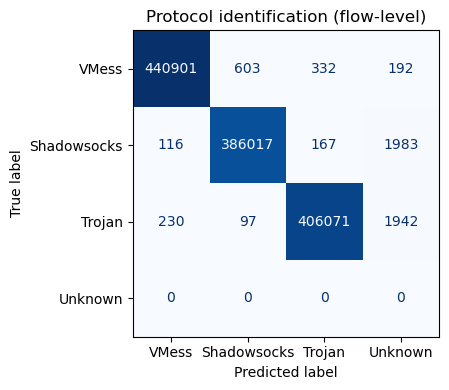

In [1]:
%load_ext autoreload
%autoreload 2

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

from WFlib.tools.extractor import *

# Use n-gram method to identify proxy protocols
root_dir = "/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract"
array_dir = f"{root_dir}/arrays"
db_file = f"{root_dir}/database.csv"
db = pd.read_csv(db_file)

UPPER_BOUND = 1500
LOWER_BOUND = -1500
WINDOW_SIZE = 2
STRIP_INDICES = {"vmess": [3, 4], "shadowsocks": [4, 5], "trojan": [3, 4]}
PROTOCOLS = ["vmess", "shadowsocks", "trojan"]
PROTOCOLS_DISPLAY = {"vmess": "VMess", "shadowsocks": "Shadowsocks", "trojan": "Trojan", "unknown": "Unknown"}
PROTOCOL_LABEL = {"vmess": 0, "shadowsocks": 1, "trojan": 2, "unknown": 3}
LABEL_TO_PROTOCOL = {v: k for k, v in PROTOCOL_LABEL.items()}
NGRAM_DB = {}
BINNERS = {}
OPTIMAL_VOCAB_SIZE = {"vmess": 90, "shadowsocks": 7, "trojan": 30}
TRAIN_SAMPLES = {'vmess': 400, 'shadowsocks': 40, 'trojan': 4}

# Train one n-gram DB and binner per protocol
for protocol in PROTOCOLS:
    with open(f"{protocol}.pkl", "rb") as f:
        flows = pickle.load(f)
    BINNERS[protocol] = PacketSizeBinner.fit_uniform(
        LOWER_BOUND, UPPER_BOUND, vocabulary_size=OPTIMAL_VOCAB_SIZE[protocol]
    )
    NGRAM_DB[protocol] = train_ngram_db(
        flows[:TRAIN_SAMPLES[protocol]], STRIP_INDICES[protocol], WINDOW_SIZE, BINNERS[protocol]
    )

# Validation sampling (per protocol). Set SAMPLE_FRAC=None to use all flows.
MIN_LEN = 15
SAMPLE_FRAC = None
SAMPLE_PER_PROTOCOL = None  # optional cap, e.g. 500; applied after fractional sample
RANDOM_SEED = 42

eval_db = db[db["protocol"].isin(PROTOCOL_LABEL)].copy()
if SAMPLE_FRAC is not None:
    eval_db = pd.concat(
        [
            g.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED)
            for _, g in eval_db.groupby("protocol")
        ],
        ignore_index=True,
    )
if SAMPLE_PER_PROTOCOL is not None:
    eval_db = (
        eval_db.groupby("protocol", group_keys=False)
        .head(SAMPLE_PER_PROTOCOL)
        .reset_index(drop=True)
    )

print("Flows per protocol (evaluation set):")
print(eval_db.groupby("protocol").size().to_string())
print(f"Total flows: {len(eval_db)}")

# One row per flow; ground truth is row["protocol"]
y_true = []
y_pred = []
n_all_zero = 0
n_ties = 0
n_skipped_short = 0
n_missing = 0

for _, row in eval_db.iterrows():
    true_p = row["protocol"]
    if true_p not in PROTOCOL_LABEL:
        continue
    path = Path(
        f"{array_dir}/{array_path(row['host'], row['id'], row['transport'], row['stream'], row['protocol'])}"
    )
    if not path.exists():
        n_missing += 1
        continue
    data = np.load(path)
    if len(data["direction"]) < MIN_LEN:
        n_skipped_short += 1
        continue
    flow = data["direction"][:MIN_LEN] * data["length"][:MIN_LEN]

    vote = flow_protocol_votes(
        flow,
        NGRAM_DB,
        BINNERS,
        PROTOCOLS,
        WINDOW_SIZE,
        strip_indices=STRIP_INDICES,
    )
    top = max(vote.values())
    if top == 0:
        vote = flow_protocol_votes_heuristic(
            flow,
            NGRAM_DB,
            BINNERS,
            PROTOCOLS,
            WINDOW_SIZE,
        )
        top = max(vote.values())
        if top == 0:
            pred_p = "unknown"
            n_all_zero += 1
        else:
            pred_p = predict_protocol_from_votes(vote)
    else:
        pred_p = predict_protocol_from_votes(vote)
    if top != 0 and sum(v == top for v in vote.values()) > 1:
        n_ties += 1
        continue

    y_true.append(PROTOCOL_LABEL[true_p])
    y_pred.append(PROTOCOL_LABEL[pred_p])

print(f"Scored flows: {len(y_true)}")
print(f"All-zero votes (predicted unknown): {n_all_zero}")
print(f"Skipped — tied top votes: {n_ties}")
print(f"Skipped — flow shorter than {MIN_LEN} packets: {n_skipped_short}")
print(f"Skipped — missing array file: {n_missing}")
print()
print(classification_report(
    y_true, y_pred, target_names=PROTOCOLS, labels=list(PROTOCOL_LABEL.values())
))
macro_p = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_r = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
print(f"macro P/R/F1: {macro_p:.4f} / {macro_r:.4f} / {macro_f1:.4f}")

cm = confusion_matrix(y_true, y_pred, labels=list(PROTOCOL_LABEL.values()))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=[PROTOCOLS_DISPLAY[p] for p in PROTOCOLS_DISPLAY]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Protocol identification (flow-level)")
plt.tight_layout()
plt.show()

In [ ]:
%load_ext autoreload
%autoreload 2

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

from WFlib.tools.extractor import *

# Use n-gram method to identify proxy protocols
root_dir = "/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract"
array_dir = f"{root_dir}/arrays"
db_file = f"{root_dir}/database.csv"
db = pd.read_csv(db_file)

UPPER_BOUND = 1500
LOWER_BOUND = -1500
WINDOW_SIZE = 2
STRIP_INDICES = {"vmess": [3, 4], "shadowsocks": [4, 5], "trojan": [3, 4]}
PROTOCOLS = ["vmess", "shadowsocks", "trojan"]
PROTOCOLS_DISPLAY = {"vmess": "VMess", "shadowsocks": "Shadowsocks", "trojan": "Trojan", "unknown": "Unknown"}
PROTOCOL_LABEL = {"vmess": 0, "shadowsocks": 1, "trojan": 2, "unknown": 3}
LABEL_TO_PROTOCOL = {v: k for k, v in PROTOCOL_LABEL.items()}
NGRAM_DB = {}
BINNERS = {}
OPTIMAL_VOCAB_SIZE = {"vmess": 90, "shadowsocks": 7, "trojan": 30}
TRAIN_SAMPLES = {'vmess': 400, 'shadowsocks': 40, 'trojan': 4}

# Train one n-gram DB and binner per protocol
for protocol in PROTOCOLS:
    with open(f"{protocol}.pkl", "rb") as f:
        flows = pickle.load(f)
    BINNERS[protocol] = PacketSizeBinner.fit_uniform(
        LOWER_BOUND, UPPER_BOUND, vocabulary_size=OPTIMAL_VOCAB_SIZE[protocol]
    )
    NGRAM_DB[protocol] = train_ngram_db(
        flows[:TRAIN_SAMPLES[protocol]], STRIP_INDICES[protocol], WINDOW_SIZE, BINNERS[protocol]
    )

# Validation sampling (per protocol). Set SAMPLE_FRAC=None to use all pcaps.
SAMPLE_FRAC = None
SAMPLE_PER_PROTOCOL = None  # optional cap, e.g. 50; applied after fractional sample
RANDOM_SEED = 42

eval_db = db[db["protocol"].isin(PROTOCOL_LABEL)]
pcap_keys = eval_db[["protocol", "host", "id"]].drop_duplicates()
if SAMPLE_FRAC is not None:
    pcap_keys = pd.concat(
        [
            g.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED)
            for _, g in pcap_keys.groupby("protocol")
        ],
        ignore_index=True,
    )
if SAMPLE_PER_PROTOCOL is not None:
    pcap_keys = (
        pcap_keys.groupby("protocol", group_keys=False)
        .head(SAMPLE_PER_PROTOCOL)
        .reset_index(drop=True)
    )
eval_db = eval_db.merge(pcap_keys, on=["protocol", "host", "id"], how="inner")

print("Pcap groups per protocol (evaluation set):")
print(pcap_keys.groupby("protocol").size().to_string())
print(f"Total pcap groups: {len(pcap_keys)}")

# One sample per (protocol, host, id); ground truth is the group protocol
y_true = []
y_pred = []
n_all_zero = 0
n_ties = 0

for (true_p, host, pcap_id), group in eval_db.groupby(["protocol", "host", "id"]):
    if true_p not in PROTOCOL_LABEL:
        continue
    paths = group.apply(
        lambda row: f"{array_dir}/{array_path(row['host'], row['id'], row['transport'], row['stream'], row['protocol'])}",
        axis=1,
    )
    vote = pcap_protocol_votes(
        paths,
        NGRAM_DB,
        BINNERS,
        PROTOCOLS,
        WINDOW_SIZE,
        strip_indices=STRIP_INDICES,
        min_len=15,
    )
    # print(vote)
    top = max(vote.values())
    if top == 0:
        # Heuristic classifier 
        vote = pcap_protocol_votes_heuristic(
            paths,
            NGRAM_DB,
            BINNERS,
            PROTOCOLS,
            WINDOW_SIZE,
        )
        top = max(vote.values())
        if top == 0:
            pred_p = "unknown"
            n_all_zero += 1
        else:
            pred_p = predict_protocol_from_votes(vote)
    else:
        pred_p = predict_protocol_from_votes(vote)
    if top != 0 and sum(v == top for v in vote.values()) > 1:
        n_ties += 1
        continue
    
    y_true.append(PROTOCOL_LABEL[true_p])
    y_pred.append(PROTOCOL_LABEL[pred_p])

print(f"Scored (unique top vote > 0): {len(y_true)}")
print(f"Skipped — all-zero votes: {n_all_zero}")
print(f"Skipped — tied top votes: {n_ties}")
print()
print(classification_report(
    y_true, y_pred, target_names=PROTOCOLS, labels=list(PROTOCOL_LABEL.values())
))
macro_p = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_r = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
print(f"macro P/R/F1: {macro_p:.4f} / {macro_r:.4f} / {macro_f1:.4f}")

cm = confusion_matrix(y_true, y_pred, labels=list(PROTOCOL_LABEL.values()))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=[PROTOCOLS_DISPLAY[p] for p in PROTOCOLS_DISPLAY]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Protocol identification (pcap-level)")
plt.tight_layout()
plt.show()